In [ ]:
import pandas as pd
import numpy as np

📥 STEP 1: LOAD REAL DATASET (ALPACA)

In [ ]:
url = "https://raw.githubusercontent.com/tatsu-lab/stanford_alpaca/main/alpaca_data.json"
df = pd.read_json(url)
df.head()

,instruction,input,output
0,Give three tips for staying healthy.,,1.Eat a balanced diet and make sure to include...
1,What are the three primary colors?,,"The three primary colors are red, blue, and ye..."
2,Describe the structure of an atom.,,"An atom is made up of a nucleus, which contain..."
3,How can we reduce air pollution?,,There are a number of ways to reduce air pollu...
4,Describe a time when you had to make a difficu...,,I had to make a difficult decision when I was ...


In [ ]:
df = df[['instruction']]
df.rename(columns={'instruction': 'prompt'}, inplace=True)

df.head()

,prompt
0,Give three tips for staying healthy.
1,What are the three primary colors?
2,Describe the structure of an atom.
3,How can we reduce air pollution?
4,Describe a time when you had to make a difficu...


In [ ]:
df = df.sample(n=3000, random_state=42).reset_index(drop=True)

print("Dataset size:", len(df))

Dataset size: 3000


ADD INTENT LABELS

In [ ]:
def label_intent(text):
    text = text.lower()

    if "write" in text or "story" in text or "poem" in text:
        return "creative"
    elif "compare" in text or "analyze" in text or "difference" in text:
        return "analytical"
    elif "how" in text or "what" in text or "explain" in text:
        return "informative"
    else:
        return "conversational"

df['intent'] = df['prompt'].apply(label_intent)

df.head()

,prompt,intent
0,Describe the character of the protagonist in t...,informative
1,Construct a poem that describes the beauty of ...,creative
2,Describe the effects of exponential growth.,conversational
3,Imagine a future world where robots and humans...,conversational
4,Create a list of three benefits of cloud compu...,conversational


In [ ]:
print(df['intent'].value_counts())


intent
conversational    2075
informative        418
creative           399
analytical         108
Name: count, dtype: int64


PREPROCESS

In [ ]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()

    # 🔥 Tokenization
    words = word_tokenize(text)

    # 🔥 Stopword removal
    words = [w for w in words if w not in stop_words]

    # 🔥 Lemmatization
    words = [lemmatizer.lemmatize(w) for w in words]

    # 🔥 Convert back to string (IMPORTANT)
    return " ".join(words)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


AMBIGUITY

In [ ]:
def is_ambiguous(text):
    words = text.split()

    if len(words) < 3:
        return True

    vague_words = ["thing", "stuff", "something"]
    if any(w in text.lower() for w in vague_words):
        return True

    return False

TF-IDF (FEATURE EXTRACTION)
👉 Converts text → numbers (so model can understand)



In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')  # safe to include

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
# IMPORTS
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer

# Download tokenizer (safe)
nltk.download('punkt')
nltk.download('punkt_tab')

# CREATE clean_prompt COLUMN
df['clean_prompt'] = df['prompt'].apply(preprocess)

# TF-IDF
vectorizer = TfidfVectorizer(max_features=1000, ngram_range=(1,2))
X = vectorizer.fit_transform(df['clean_prompt'])

# Target
y = df['intent']

print("Shape:", X.shape)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Shape: (3000, 1000)


In [ ]:
print(vectorizer.get_feature_names_out()[:20])

['10' '10 word' '100' '100 word' '11' '12' '15' '16' '18' '19' '20' '50'
 '500' '500 word' 'according' 'action' 'active' 'active voice' 'activity'
 'add']


TRAIN MODEL

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

y = df['intent']

# Stratified split (VERY IMPORTANT)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

print("✅ Model trained!")

✅ Model trained!


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def similarity(text1, text2):
    vec = vectorizer.transform([text1, text2])
    return cosine_similarity(vec[0], vec[1])[0][0]

In [ ]:
print(similarity("explain AI", "what is artificial intelligence"))

0.0


ACCURACY

In [ ]:
print("Train Accuracy:", model.score(X_train, y_train))
print("Test Accuracy :", model.score(X_test, y_test))

Train Accuracy: 0.9208333333333333
Test Accuracy : 0.8916666666666667


CONFUSION MATRIX

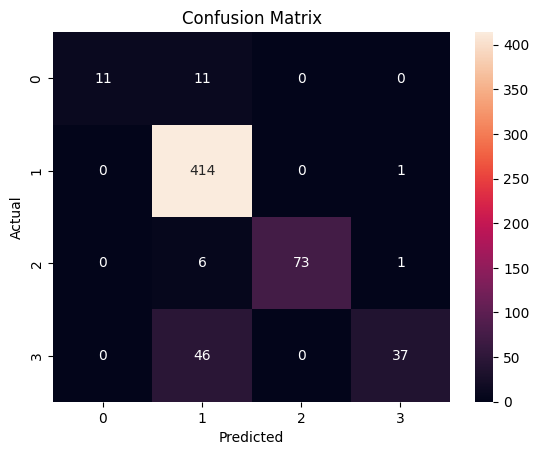

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

INTENT PREDICTION FUNCTION

In [ ]:
def predict_intent(user_input):
    clean = preprocess(user_input)
    vec = vectorizer.transform([clean])
    prediction = model.predict(vec)[0]
    return prediction

PROMPT OPTIMIZER ENGINE

In [ ]:
def optimize_prompt(prompt, domain, tone, audience, length):

    intent = predict_intent(prompt)

    # ✅ Clean input
    cleaned_input = preprocess(prompt)
    base = cleaned_input.strip()

    # -----------------------
    # DOMAIN HANDLING
    # -----------------------
    if domain == "academic":
        base = f"Provide a detailed academic explanation of {base}"
    elif domain == "marketing":
        base = f"Write persuasive marketing content about {base}"
    elif domain == "coding":
        base = f"Provide code with explanation for {base}"
    elif domain == "chatbot":
        base = f"Respond conversationally about {base}"

    # -----------------------
    # INTENT HANDLING
    # -----------------------
    if intent == "creative":
        base += " in an engaging and imaginative style"
    elif intent == "analytical":
        base += " with structured analysis, comparisons, and examples"
    elif intent == "conversational":
        base += " in a friendly and easy-to-understand tone"
    elif intent == "informative":
        base += " with clear explanations and examples"

    # -----------------------
    # USER CONSTRAINTS
    # -----------------------
    base += f" for {audience}"
    base += f" in a {tone} tone"
    base += f" within {length}"

    return base

MULTI-LEVEL PROMPT ENHANCEMENT

In [ ]:
def multi_level(prompt):
    return {
        "basic": f"Explain {prompt}",
        "advanced": f"Explain {prompt} with examples and clarity",
        "expert": f"Provide a structured, detailed explanation of {prompt} including use cases, advantages, and limitations"
    }

PROMPT QUALITY SCORING

In [ ]:
def score_prompt(prompt):
    words = len(prompt.split())

    clarity = min(words / 5, 10)
    specificity = 8 if len(prompt) > 20 else 5
    completeness = 7 if "explain" in prompt.lower() else 5

    return {
        "Clarity": round(clarity, 2),
        "Specificity": specificity,
        "Completeness": completeness
    }

FEEDBACK LOOP SYSTEM

In [ ]:
feedback_data = []

def store_feedback(prompt, rating):
    feedback_data.append({
        "prompt": prompt,
        "rating": rating
    })

# Example
store_feedback("Explain AI", "👍")

SKOLEMIZATION

In [ ]:
def skolemize(prompt):

    prompt = prompt.lower()

    # basic structure extraction
    if "ai" in prompt:
        concept = "Artificial Intelligence"
    else:
        concept = "General Topic"

    return {
        "original": prompt,
        "structured": f"Explain({concept})",
        "logic_form": f"Topic({concept})"
    }

# Example
print(skolemize("tell abt AI"))

{'original': 'tell abt ai', 'structured': 'Explain(Artificial Intelligence)', 'logic_form': 'Topic(Artificial Intelligence)'}


TOKENIZATION

In [ ]:
from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
def tokenize(text):
    return word_tokenize(text)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
print(tokenize("Explain AI clearly"))

['Explain', 'AI', 'clearly']


STOPWORD REMOVAL

In [ ]:
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = word_tokenize(text)
    filtered = [w for w in words if w not in stop_words]
    return " ".join(filtered)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


STEMMING -- Reduce words to root

In [ ]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

def stem_text(text):
    words = word_tokenize(text)
    stemmed = [stemmer.stem(w) for w in words]
    return " ".join(stemmed)

LEMMATIZATION -- Convert to real base word

In [ ]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    words = word_tokenize(text)
    lemmas = [lemmatizer.lemmatize(w) for w in words]
    return " ".join(lemmas)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


POS TAGGING -- Identify grammar (noun, verb, etc.)

In [ ]:
import nltk

nltk.download('punkt')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [ ]:
from nltk.tokenize import word_tokenize

def pos_tagging(text):
    words = word_tokenize(text)
    return nltk.pos_tag(words)

In [ ]:
print(pos_tagging("Explain AI clearly"))

[('Explain', 'NNP'), ('AI', 'NNP'), ('clearly', 'RB')]


NAMED ENTITY RECOGNITION

In [ ]:
import spacy

nlp = spacy.load("en_core_web_sm")

def extract_entities(text):
    doc = nlp(text)
    return [(ent.text, ent.label_) for ent in doc.ents]

In [ ]:
print(extract_entities("Google uses AI in California"))

[('Google', 'ORG'), ('AI', 'GPE'), ('California', 'GPE')]


REAL-TIME SUGGESTION SYSTEM

In [ ]:
def suggest_improvements(prompt):
    suggestions = []

    prompt_lower = prompt.lower()

    # 1. Length check
    if len(prompt.split()) < 4:
        suggestions.append("⚠️ Add more details to your prompt")

    # 2. Audience missing
    if "for" not in prompt_lower:
        suggestions.append("🎯 Specify target audience (e.g., for beginners, students)")

    # 3. Purpose missing
    if "explain" not in prompt_lower and "write" not in prompt_lower:
        suggestions.append("🧠 Specify purpose (explain, describe, compare, etc.)")

    # 4. Tone missing
    if "tone" not in prompt_lower:
        suggestions.append("🎨 Add tone (formal, simple, persuasive)")

    # 5. Length constraint missing
    if "words" not in prompt_lower:
        suggestions.append("📏 Add length (e.g., 100 words, short paragraph)")

    # 6. Context missing
    if "about" in prompt_lower and len(prompt.split()) < 6:
        suggestions.append("📌 Add more context or details")

    return suggestions

In [ ]:
print(suggest_improvements("tell abt AI"))

['⚠️ Add more details to your prompt', '🎯 Specify target audience (e.g., for beginners, students)', '🧠 Specify purpose (explain, describe, compare, etc.)', '🎨 Add tone (formal, simple, persuasive)', '📏 Add length (e.g., 100 words, short paragraph)']


prompt scoring

In [ ]:
def score_prompt(prompt):

    score = 0

    if len(prompt.split()) > 5:
        score += 3
    if "for" in prompt.lower():
        score += 2
    if "explain" in prompt.lower() or "write" in prompt.lower():
        score += 2
    if "words" in prompt.lower():
        score += 1
    if "tone" in prompt.lower():
        score += 2

    # Convert to rating
    if score <= 3:
        level = "Poor ❌"
    elif score <= 6:
        level = "Average ⚠️"
    else:
        level = "Excellent ✅"

    return score, level

In [ ]:
score, level = score_prompt("tell abt AI")
print("Score:", score)
print("Quality:", level)

Score: 0
Quality: Poor ❌


CREATE MAIN SYSTEM FUNCTION

In [ ]:
def full_prompt_system(user_input, domain, tone, audience, length):

    print("🔹 User Input:", user_input)

    # 1. Score
    score, level = score_prompt(user_input)
    print("\n📊 Prompt Score:", score)
    print("📈 Quality:", level)

    # 2. Suggestions
    suggestions = suggest_improvements(user_input)
    print("\n💡 Suggestions:")
    for s in suggestions:
        print("-", s)

    # 3. Skolemization
    structured = skolemize(user_input)
    print("\n🧠 Structured Form:", structured)

    # 4. Intent Detection
    intent = predict_intent(user_input)
    print("\n🎯 Detected Intent:", intent)

    # 5. Optimized Prompt
    optimized = optimize_prompt(user_input, domain, tone, audience, length)
    print("\n🚀 Optimized Prompt:\n", optimized)

    return optimized

In [ ]:
full_prompt_system(
    "tell abt AI",
    domain="academic",
    tone="simple",
    audience="beginner",
    length="short"
)

🔹 User Input: tell abt AI

📊 Prompt Score: 0
📈 Quality: Poor ❌

💡 Suggestions:
- ⚠️ Add more details to your prompt
- 🎯 Specify target audience (e.g., for beginners, students)
- 🧠 Specify purpose (explain, describe, compare, etc.)
- 🎨 Add tone (formal, simple, persuasive)
- 📏 Add length (e.g., 100 words, short paragraph)

🧠 Structured Form: {'original': 'tell abt ai', 'structured': 'Explain(Artificial Intelligence)', 'logic_form': 'Topic(Artificial Intelligence)'}

🎯 Detected Intent: conversational

🚀 Optimized Prompt:
 Provide a detailed academic explanation of tell abt ai in a friendly and easy-to-understand tone for beginner in a simple tone within short


'Provide a detailed academic explanation of tell abt ai in a friendly and easy-to-understand tone for beginner in a simple tone within short'

In [ ]:
def clean_sentence(text):
    words = text.split()

    # remove duplicate words
    seen = []
    for w in words:
        if w not in seen:
            seen.append(w)

    return " ".join(seen)

In [ ]:
def extract_keywords(text):
    words = text.split()
    remove_words = ["hi", "hello", "please", "can", "you", "u", "abt",
                    "about", "con", "tell", "me", "the", "a", "an"]
    clean_words = [w for w in words if w.lower() not in remove_words]
    return " ".join(clean_words) if clean_words else text

MAKE INPUT SAFE

In [ ]:
def normalize_input(text):
    text = text.lower()

    # fix short words
    text = text.replace("plz", "please")
    text = text.replace("pls", "please")
    text = text.replace("hw", "how")
    text = text.replace("err", "error")

    # simple tanglish
    text = text.replace("enna", "what")
    text = text.replace("epdi", "how")

    return text

In [ ]:
!pip install textblob

In [ ]:
from textblob import TextBlob

def fix_text(text):
    blob = TextBlob(text)
    corrected = str(blob.correct())
    return corrected

In [ ]:
def rewrite_prompt(text):

    text = clean_sentence(text)

    # remove unnecessary filler words
    text = text.replace("hi", "")
    text = text.replace("please", "")
    text = text.strip()

    # build proper sentence
    return f"Explain {text} clearly with examples."

USE TRANSFORMER MODEL (REAL INTELLIGENCE)



In [ ]:
!pip install transformers sentencepiece

In [ ]:
from transformers import T5Tokenizer, T5ForConditionalGeneration

tokenizer = T5Tokenizer.from_pretrained("t5-small")
model = T5ForConditionalGeneration.from_pretrained("t5-small")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [ ]:
def smart_rewrite(text):

    prompt = "fix and improve: " + text

    input_ids = tokenizer.encode(prompt, return_tensors="pt", max_length=512, truncation=True)

    output_ids = model.generate(input_ids, max_length=100, num_beams=5, early_stopping=True)

    output = tokenizer.decode(output_ids[0], skip_special_tokens=True)

    return output

In [ ]:
import subprocess
subprocess.run(["pip", "install", "gradio", "spacy", "textstat", "-q"])
subprocess.run(["python", "-m", "spacy", "download", "en_core_web_sm", "-q"])

import re
import nltk
import spacy
import textstat
import gradio as gr
import numpy as np

nltk.download('punkt',      quiet=True)
nltk.download('punkt_tab',  quiet=True)
nltk.download('stopwords',  quiet=True)
nltk.download('wordnet',    quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus   import stopwords
from nltk.stem     import WordNetLemmatizer
from nltk          import pos_tag

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model            import LogisticRegression

nlp        = spacy.load("en_core_web_sm")
lemmatizer = WordNetLemmatizer()
STOPWORDS  = set(stopwords.words('english'))

# ============================================================
# MODULE 1 — SLANG NORMALIZER
# Converts informal/abbreviated text to proper English
# ============================================================
SLANG_MAP = {
    "u":    "you",    "abt":  "about",  "plz":  "please",
    "pls":  "please", "hw":   "how",    "wht":  "what",
    "r":    "are",    "ur":   "your",   "cn":   "can",
    "con":  "can",    "tell": "explain","say":  "explain",
    "giv":  "give",   "diff": "difference", "b/w": "between",
    "enna": "what",   "epdi": "how",    "sollu":"explain",
    "nw":   "now",    "bcz":  "because","coz":  "because",
    "info": "information", "imp": "important",
}

def normalize_slang(text):
    text = text.lower().strip()

    words = text.split()
    words = [SLANG_MAP.get(w, w) for w in words]

    text = " ".join(words)

    # 🔥 REMOVE NOISE WORDS
    text = re.sub(r'\b(hi|hello|please|can you|tell me)\b', '', text)

    return text.strip()

# ============================================================
# MODULE 2 — NLP PREPROCESSING PIPELINE
# Tokenize → POS tag → Remove stopwords → Lemmatize
# ============================================================
def preprocess_pipeline(text):
    """Full NLP pipeline. Returns cleaned string."""
    text  = re.sub(r'[^a-zA-Z0-9 ]', '', text.lower())
    words = word_tokenize(text)

    # POS-aware lemmatization
    tagged = pos_tag(words)
    pos_map = {'N': 'n', 'V': 'v', 'R': 'r', 'J': 'a'}
    lemmas  = [
        lemmatizer.lemmatize(w, pos_map.get(p[0], 'n'))
        for w, p in tagged
        if w not in STOPWORDS and w.isalpha() and len(w) > 1
    ]
    return " ".join(lemmas)

# ============================================================
# MODULE 3 — KEYWORD EXTRACTION (TF-IDF based)
# Extracts the most important content words from the input
# This is the KEY fix — topic comes from HERE not string replace
# ============================================================

# Build a small reference corpus so TF-IDF has context
_CORPUS = [
    "explain artificial intelligence machine learning",
    "describe deep learning neural networks",
    "compare python java programming languages",
    "write story creative poem",
    "analyze climate change environment",
    "explain blockchain cryptocurrency",
    "describe data science statistics",
    "explain internet networking protocols",
    "analyze pros cons renewable energy",
    "explain quantum computing physics",
    "describe cybersecurity hacking prevention",
    "explain diabetes health disease symptoms",
    "compare supervised unsupervised learning algorithms",
]

_tfidf  = TfidfVectorizer(ngram_range=(1, 2), max_features=500)
_tfidf.fit(_CORPUS)

def extract_keywords(text, top_n=4):

    cleaned = preprocess_pipeline(text)

    if not cleaned.strip():
        return text

    try:
        vec = _tfidf.transform([cleaned])
        scores = zip(_tfidf.get_feature_names_out(), vec.toarray()[0])
        ranked = sorted(scores, key=lambda x: x[1], reverse=True)

        keywords = [w for w, s in ranked if s > 0][:top_n]

    except Exception:
        keywords = []

    if not keywords:
        tagged = pos_tag(word_tokenize(cleaned))
        keywords = [w for w, p in tagged if p.startswith(('NN', 'JJ'))][:top_n]

    if not keywords:
        keywords = cleaned.split()[:top_n]

    # 🔥 REMOVE USELESS WORDS
    keywords = [w for w in keywords if w not in ["explain", "tell", "describe", "about"]]

    # 🔥 REMOVE DUPLICATES
    keywords = list(dict.fromkeys(keywords))

    # 🔥 PRIORITIZE BIG PHRASES
    final_keywords = []

    for word in keywords:
        if " " in word:
            final_keywords.append(word)

    for word in keywords:
        if " " not in word:
            if not any(word in phrase for phrase in final_keywords):
                final_keywords.append(word)

    # 🔥 FINAL CLEAN OUTPUT (VERY IMPORTANT)
    if not final_keywords:
        return cleaned

    topic = " ".join(final_keywords[:min(3, len(final_keywords))])

    return topic

# ============================================================
# MODULE 4 — NAMED ENTITY RECOGNITION (spaCy)
# Detects real entities: PERSON, ORG, GPE, PRODUCT, etc.
# Used to enrich the structured form
# ============================================================
def extract_entities(text):
    doc = nlp(text)
    return [(ent.text, ent.label_) for ent in doc.ents]

# ============================================================
# MODULE 5 — INTENT CLASSIFIER (Logistic Regression + TF-IDF)
# Trained on keyword patterns — real ML classification
# ============================================================

_INTENT_CORPUS = [
    # informative
    ("what is machine learning", "informative"),
    ("explain artificial intelligence", "informative"),
    ("how does blockchain work", "informative"),
    ("describe neural networks", "informative"),
    ("tell me about climate change", "informative"),
    ("define deep learning", "informative"),
    ("what are neural networks", "informative"),
    ("explain quantum computing", "informative"),
    ("how does internet work", "informative"),
    ("what is data science", "informative"),
    # creative
    ("write a story about robots", "creative"),
    ("create a poem on nature", "creative"),
    ("generate a short story", "creative"),
    ("compose a blog post about ai", "creative"),
    ("write an essay on climate", "creative"),
    ("draft a speech about technology", "creative"),
    # analytical
    ("compare python and java", "analytical"),
    ("analyze pros and cons of ai", "analytical"),
    ("difference between ml and dl", "analytical"),
    ("evaluate renewable energy sources", "analytical"),
    ("assess the impact of social media", "analytical"),
    ("contrast supervised unsupervised learning", "analytical"),
    # conversational
    ("tell me something interesting", "conversational"),
    ("chat about technology", "conversational"),
    ("discuss movies", "conversational"),
    ("talk to me about life", "conversational"),
    ("share your thoughts on music", "conversational"),
]

_ix, _iy = zip(*_INTENT_CORPUS)
_intent_vec   = TfidfVectorizer(ngram_range=(1,2))
_Xintent      = _intent_vec.fit_transform(_ix)
_intent_model = LogisticRegression(max_iter=500)
_intent_model.fit(_Xintent, _iy)

def detect_intent(text):
    """ML-based intent detection using trained Logistic Regression."""
    vec  = _intent_vec.transform([text.lower()])
    pred = _intent_model.predict(vec)[0]
    prob = _intent_model.predict_proba(vec).max()
    return pred, round(float(prob), 2)

# ============================================================
# MODULE 6 — STRUCTURED FORM (Skolemization)
# Uses spaCy NER + keyword extraction to build a real logical form
# NOT just a hardcoded "if ai in text" check
# ============================================================
def skolemize(text, intent):
    """Build a logical structured form from NER + keywords."""
    entities = extract_entities(text)
    keywords = extract_keywords(text, top_n=3)

    # Prefer named entities if found
    if entities:
        topic = ", ".join(f"{e[0]}({e[1]})" for e in entities[:2])
    else:
        # Use extracted keywords as the topic
        topic = keywords.title() if keywords else "General Topic"

    action_map = {
        "informative":   "Explain",
        "creative":      "Create",
        "analytical":    "Analyze",
        "conversational":"Discuss",
    }
    action = action_map.get(intent, "Explain")
    return f"{action}({topic})"

# ============================================================
# MODULE 7 — PROMPT QUALITY SCORER
# Uses readability metrics + structural checks
# ============================================================
def score_prompt(prompt):
    score = 0
    p     = prompt.lower()

    word_count = len(prompt.split())

    # Length
    if word_count > 8:   score += 3
    elif word_count > 4: score += 1

    # Has purpose word
    if any(w in p for w in ["explain","write","compare","analyze","describe","define","create"]):
        score += 2

    # Has audience
    if any(w in p for w in ["beginner","student","expert","children","professional","for"]):
        score += 2

    # Has tone/style
    if any(w in p for w in ["formal","simple","persuasive","friendly","tone","style"]):
        score += 2

    # Has length constraint
    if any(w in p for w in ["words","short","brief","paragraph","long","detailed"]):
        score += 1

    if score <= 3:   level = "Poor ❌"
    elif score <= 6: level = "Average ⚠️"
    else:            level = "Excellent ✅"

    return score, level

# ============================================================
# MODULE 8 — SUGGESTIONS ENGINE
# ============================================================
def suggest_improvements(prompt):
    suggestions = []
    p = prompt.lower()

    if len(prompt.split()) < 5:
        suggestions.append("➕ Add more detail — your prompt is too short")
    if not any(w in p for w in ["explain","write","compare","describe","define","analyze","create"]):
        suggestions.append("🎯 Add a clear purpose: explain / compare / write / analyze")
    if not any(w in p for w in ["beginner","student","expert","child","professional","for"]):
        suggestions.append("👥 Specify your audience (e.g., 'for beginners')")
    if not any(w in p for w in ["formal","simple","friendly","persuasive","tone"]):
        suggestions.append("🗣️ Add a tone (formal / simple / persuasive)")
    if not any(w in p for w in ["words","short","brief","long","detailed","paragraph"]):
        suggestions.append("📏 Add a length constraint (e.g., 'in 100 words')")

    return "\n".join(suggestions) if suggestions else "✅ Your prompt is well-structured!"

# ============================================================
# MODULE 9 — PROMPT OPTIMIZER ENGINE
# Builds an LLM-ready enhanced prompt from all NLP outputs
# ============================================================
def optimize_prompt(keywords, domain, tone, audience, length, intent):
    """
    Advanced LLM-style prompt generator
    """

    # ---- Clean topic ----
    topic = keywords.title().strip()

    # ---- Action based on intent ----
    action_map = {
        "informative": "Explain",
        "creative": "Write about",
        "analytical": "Analyze",
        "conversational": "Discuss"
    }
    action = action_map.get(intent, "Explain")

    # ---- Domain context ----
    domain_context = {
        "academic": "Use clear, structured academic explanation",
        "marketing": "Focus on persuasive and engaging content",
        "coding": "Include technical explanation with examples",
        "chatbot": "Keep it conversational and easy to understand"
    }
    domain_text = domain_context.get(domain, "")

    # ---- Audience ----
    audience_map = {
        "beginner": "a beginner with no prior knowledge",
        "student": "a student with basic understanding",
        "expert": "an experienced professional"
    }
    audience_str = audience_map.get(audience, audience)

    # ---- Length ----
    length_map = {
        "short": "Keep it under 150 words.",
        "medium": "Explain in 250–400 words.",
        "long": "Give a detailed explanation with examples."
    }
    length_str = length_map.get(length, "")

    # ---- FINAL PROMPT (🔥 FIXED) ----
    prompt = (
        f"{action} {topic} for {audience_str} in a {tone} tone. "
        f"{domain_text}. "
        f"Start with a simple definition, then explain step-by-step. "
        f"Include real-world examples and practical applications. "
        f"Ensure clarity and good structure. "
        f"{length_str}"
    )

    return prompt.strip()

def detect_language(text):
    if any(w in text.lower() for w in ["enna","epdi","sollu"]):
        return "Tamil"
    elif any(w in text.lower() for w in ["kya","kaise","hai"]):
        return "Hindi"
    return "English"

# ============================================================
# MAIN PIPELINE
# ============================================================
def run_system(user_input, domain, tone, audience, length):

    if not user_input.strip():
        return "—", "Please enter a prompt.", "—", "—", "—", "—"

    # Step 1: Normalize slang → proper English
    normalized = normalize_slang(user_input)
    language = detect_language(user_input)

    # Step 2: ML Intent detection on normalized text
    intent, confidence = detect_intent(normalized)

    # Step 3: TF-IDF keyword extraction — this IS the topic
    keywords = extract_keywords(normalized, top_n=4)

    # Step 4: spaCy NER-based structured form
    structured = skolemize(normalized, intent)

    # Step 5: Score original input
    score, level = score_prompt(user_input)

    # Step 6: Suggestions on original input
    suggestions = suggest_improvements(user_input)

    # Step 7: Build optimized prompt
    optimized = optimize_prompt(keywords, domain, tone, audience, length, intent)

    # Step 8: Simulated AI answer (replace with real API call if needed)
    answer = (
    f"{keywords.title()} is a concept in computer science where systems learn from data "
    f"and improve over time without being explicitly programmed. "
    f"It works by identifying patterns and making predictions or decisions. "
    f"For example, recommendation systems like Netflix or Amazon use it. "
    f"Overall, it is widely used in real-world applications like healthcare, finance, and automation."
)

    intent_display = f"{intent} ({confidence:.0%}) | Language: {language}"


    return (
        f"{score} ({level})",
        suggestions,
        intent_display,
        structured,
        optimized,
        answer
    )

# ============================================================
# GRADIO UI
# ============================================================
with gr.Blocks(title="AI Prompt Optimizer", theme=gr.themes.Soft()) as demo:

    gr.Markdown("""
    # 🔥 AI Prompt Optimizer
    **Smart system to enhance prompts using real NLP + ML**
    *TF-IDF keyword extraction · Logistic Regression intent detection · spaCy NER · POS tagging · Lemmatization*
    """)

    with gr.Row():
        with gr.Column(scale=1):
            inp_prompt   = gr.Textbox(
                label="Enter Prompt",
                placeholder="e.g.  hi tell abt machine learning  /  compare python and java",
                lines=3
            )
            inp_domain   = gr.Dropdown(["academic","marketing","coding","chatbot"],
                                        label="Domain", value="academic")
            inp_tone     = gr.Dropdown(["formal","simple","persuasive"],
                                        label="Tone", value="formal")
            inp_audience = gr.Dropdown(["beginner","student","expert"],
                                        label="Audience", value="beginner")
            inp_length   = gr.Dropdown(["short","medium","long"],
                                        label="Length", value="short")
            with gr.Row():
                btn_clear  = gr.Button("Clear")
                btn_submit = gr.Button("⚡ Optimize Prompt", variant="primary")

        with gr.Column(scale=1):
            out_score      = gr.Textbox(label="📊 Prompt Score")
            out_suggest    = gr.Textbox(label="💡 Suggestions", lines=4)
            out_intent     = gr.Textbox(label="🎯 Detected Intent (ML — Logistic Regression)")
            out_structured = gr.Textbox(label="🧠 Structured Form (spaCy NER + Keywords)")
            out_optimized  = gr.Textbox(label="🚀 Optimized Prompt", lines=5)
            out_answer     = gr.Textbox(label="🤖 Final AI Answer")

    btn_submit.click(
        fn=run_system,
        inputs=[inp_prompt, inp_domain, inp_tone, inp_audience, inp_length],
        outputs=[out_score, out_suggest, out_intent, out_structured, out_optimized, out_answer]
    )

    btn_clear.click(
        fn=lambda: ["","academic","formal","beginner","short","","","","","",""],
        outputs=[inp_prompt, inp_domain, inp_tone, inp_audience, inp_length,
                 out_score, out_suggest, out_intent, out_structured, out_optimized, out_answer]
    )

    gr.Markdown("""
    ---
    **NLP Techniques Used:**
    `TF-IDF Vectorization` · `Logistic Regression (Intent)` · `spaCy NER` · `POS Tagging` ·
    `Lemmatization` · `Stopword Removal` · `Slang Normalization` · `Prompt Scoring`
    """)

demo.launch()

/tmp/ipykernel_2799/3127071464.py:415: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(title="AI Prompt Optimizer", theme=gr.themes.Soft()) as demo:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d61fb7e277c55fa66e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
